# Tratar dados

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
dfTest = pd.read_csv('test_data.csv',encoding='latin1')
dfTrain = pd.read_csv('training_data.csv',encoding='latin1')

In [4]:
dfTest.head()

,city_name,record_date,AVERAGE_FREE_FLOW_SPEED,AVERAGE_TIME_DIFF,AVERAGE_FREE_FLOW_TIME,LUMINOSITY,AVERAGE_TEMPERATURE,AVERAGE_ATMOSP_PRESSURE,AVERAGE_HUMIDITY,AVERAGE_WIND_SPEED,AVERAGE_CLOUDINESS,AVERAGE_PRECIPITATION,AVERAGE_RAIN
0,Porto,2019-02-13 23:00:00,39.2,0.0,91.0,DARK,8.0,1026.0,71.0,1.0,céu claro,0.0,NaN
1,Porto,2018-11-28 20:00:00,42.5,12.2,76.8,DARK,11.0,1020.0,93.0,4.0,nuvens dispersas,0.0,NaN
2,Porto,2018-08-14 05:00:00,45.9,0.0,86.3,DARK,14.0,1017.0,93.0,0.0,NaN,0.0,NaN
3,Porto,2019-07-06 17:00:00,33.2,51.7,89.9,LIGHT,22.0,1016.0,77.0,4.0,céu pouco nublado,0.0,NaN
4,Porto,2018-10-15 06:00:00,44.0,3.5,85.5,DARK,12.0,1004.0,100.0,9.0,NaN,0.0,chuva fraca


In [5]:
dfTrain.head()

,city_name,record_date,AVERAGE_SPEED_DIFF,AVERAGE_FREE_FLOW_SPEED,AVERAGE_TIME_DIFF,AVERAGE_FREE_FLOW_TIME,LUMINOSITY,AVERAGE_TEMPERATURE,AVERAGE_ATMOSP_PRESSURE,AVERAGE_HUMIDITY,AVERAGE_WIND_SPEED,AVERAGE_CLOUDINESS,AVERAGE_PRECIPITATION,AVERAGE_RAIN
0,Porto,2019-08-29 07:00:00,Medium,41.5,11.5,71.4,LIGHT,15.0,1019.0,100.0,3.0,NaN,0.0,NaN
1,Porto,2018-08-10 14:00:00,High,41.7,48.3,87.4,LIGHT,21.0,1021.0,53.0,5.0,céu claro,0.0,NaN
2,Porto,2019-09-01 16:00:00,High,38.6,38.4,85.2,LIGHT,26.0,1014.0,61.0,4.0,NaN,0.0,NaN
3,Porto,2019-02-26 11:00:00,High,37.4,61.0,94.1,LIGHT,18.0,1025.0,48.0,4.0,céu claro,0.0,NaN
4,Porto,2019-06-06 12:00:00,Medium,41.6,50.4,77.0,LIGHT,15.0,1008.0,82.0,10.0,NaN,0.0,NaN


In [6]:
dfTest.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   city_name                1500 non-null   object 
 1   record_date              1500 non-null   object 
 2   AVERAGE_FREE_FLOW_SPEED  1500 non-null   float64
 3   AVERAGE_TIME_DIFF        1500 non-null   float64
 4   AVERAGE_FREE_FLOW_TIME   1500 non-null   float64
 5   LUMINOSITY               1500 non-null   object 
 6   AVERAGE_TEMPERATURE      1500 non-null   float64
 7   AVERAGE_ATMOSP_PRESSURE  1500 non-null   float64
 8   AVERAGE_HUMIDITY         1500 non-null   float64
 9   AVERAGE_WIND_SPEED       1500 non-null   float64
 10  AVERAGE_CLOUDINESS       901 non-null    object 
 11  AVERAGE_PRECIPITATION    1500 non-null   float64
 12  AVERAGE_RAIN             140 non-null    object 
dtypes: float64(8), object(5)
memory usage: 152.5+ KB


## Converter de float64 para float32 usa menos memória

In [7]:
floatFeatures = dfTest.select_dtypes(include='float64')
dfTest[floatFeatures.columns] = dfTest[floatFeatures.columns].astype(np.float32)

In [8]:
dfTrain.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6812 entries, 0 to 6811
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   city_name                6812 non-null   object 
 1   record_date              6812 non-null   object 
 2   AVERAGE_SPEED_DIFF       4612 non-null   object 
 3   AVERAGE_FREE_FLOW_SPEED  6812 non-null   float64
 4   AVERAGE_TIME_DIFF        6812 non-null   float64
 5   AVERAGE_FREE_FLOW_TIME   6812 non-null   float64
 6   LUMINOSITY               6812 non-null   object 
 7   AVERAGE_TEMPERATURE      6812 non-null   float64
 8   AVERAGE_ATMOSP_PRESSURE  6812 non-null   float64
 9   AVERAGE_HUMIDITY         6812 non-null   float64
 10  AVERAGE_WIND_SPEED       6812 non-null   float64
 11  AVERAGE_CLOUDINESS       4130 non-null   object 
 12  AVERAGE_PRECIPITATION    6812 non-null   float64
 13  AVERAGE_RAIN             563 non-null    object 
dtypes: float64(8), object(6)

In [9]:
floatFeatures = dfTrain.select_dtypes(include='float64')
dfTrain[floatFeatures.columns] = dfTrain[floatFeatures.columns].astype(np.float32)

# Converter dados para númericos

In [10]:
dfTrain['record_date'] = pd.to_datetime(dfTrain['record_date'])

# Extrair partes da data
dfTrain['year'] = dfTrain['record_date'].dt.year
dfTrain['month'] = dfTrain['record_date'].dt.month
dfTrain['day'] = dfTrain['record_date'].dt.day
dfTrain['hour'] = dfTrain['record_date'].dt.hour

dfTrain['dayOfWeek'] = dfTrain['record_date'].dt.dayofweek
dfTrain['isRushHour'] = ((dfTrain['hour'] >= 7) & (dfTrain['hour'] <= 10) | 
                          (dfTrain['hour'] >= 16) & (dfTrain['hour'] <= 21)).astype(int)

dfTest['record_date'] = pd.to_datetime(dfTest['record_date'])

# Extrair partes da data
dfTest['year'] = dfTest['record_date'].dt.year
dfTest['month'] = dfTest['record_date'].dt.month
dfTest['day'] = dfTest['record_date'].dt.day
dfTest['hour'] = dfTest['record_date'].dt.hour

dfTest['dayOfWeek'] = dfTest['record_date'].dt.dayofweek
dfTest['isRushHour'] = ((dfTest['hour'] >= 7) & (dfTest['hour'] <= 10) | 
                          (dfTest['hour'] >= 16) & (dfTest['hour'] <= 21)).astype(int)

In [11]:
dfTest['LUMINOSITY'].unique()

array(['DARK', 'LIGHT', 'LOW_LIGHT'], dtype=object)

In [12]:
dfTrain['LUMINOSITY'].unique()

array(['LIGHT', 'LOW_LIGHT', 'DARK'], dtype=object)

In [13]:
mappingLuminosity = {
    'DARK': 0,
    'LOW_LIGHT': 1,
    'LIGHT': 2
}

dfTest['LUMINOSITY'] = dfTest['LUMINOSITY'].map(mappingLuminosity)
dfTrain['LUMINOSITY'] = dfTrain['LUMINOSITY'].map(mappingLuminosity)

dfTest['LUMINOSITY'] = dfTest['LUMINOSITY'].fillna(-1)
dfTrain['LUMINOSITY'] = dfTrain['LUMINOSITY'].fillna(-1)

In [14]:
dfTest['AVERAGE_CLOUDINESS'].unique()

array(['céu claro', 'nuvens dispersas', nan, 'céu pouco nublado',
       'nuvens quebradas', 'algumas nuvens', 'nuvens quebrados',
       'nublado', 'céu limpo', 'tempo nublado'], dtype=object)

In [15]:
dfTrain['AVERAGE_CLOUDINESS'].unique()

array([nan, 'céu claro', 'nuvens dispersas', 'céu pouco nublado',
       'céu limpo', 'algumas nuvens', 'nuvens quebrados', 'tempo nublado',
       'nuvens quebradas', 'nublado'], dtype=object)

In [16]:
mappingCloudiness = {
    'céu limpo': 0,
    'céu claro': 0,
    'céu pouco nublado': 1,
    'algumas nuvens': 1,
    'nuvens dispersas': 2,
    'nuvens quebradas': 3,
    'nuvens quebrados': 3,
    'nublado': 4,
    'tempo nublado': 4
}

dfTest['AVERAGE_CLOUDINESS'] = dfTest['AVERAGE_CLOUDINESS'].map(mappingCloudiness)
dfTrain['AVERAGE_CLOUDINESS'] = dfTrain['AVERAGE_CLOUDINESS'].map(mappingCloudiness)

dfTest['AVERAGE_CLOUDINESS'] = dfTest['AVERAGE_CLOUDINESS'].fillna(-1)
dfTrain['AVERAGE_CLOUDINESS'] = dfTrain['AVERAGE_CLOUDINESS'].fillna(-1)

In [17]:
dfTest['AVERAGE_RAIN'].unique()

array([nan, 'chuva fraca', 'chuva moderada', 'chuva', 'aguaceiros fracos',
       'chuva leve', 'aguaceiros', 'trovoada com chuva', 'chuvisco fraco',
       'trovoada com chuva leve'], dtype=object)

In [18]:
dfTrain['AVERAGE_RAIN'].unique()

array([nan, 'chuva fraca', 'chuva', 'chuva leve', 'chuvisco fraco',
       'chuva moderada', 'trovoada com chuva leve', 'aguaceiros',
       'aguaceiros fracos', 'chuva de intensidade pesada',
       'trovoada com chuva', 'chuva de intensidade pesado', 'chuva forte',
       'chuvisco e chuva fraca'], dtype=object)

In [19]:
mappingRain = {
    'chuvisco fraco': 0,
    'chuvisco e chuva fraca': 1,
    'chuva fraca': 1,
    'chuva leve': 1,
    'aguaceiros fracos': 2,
    'chuva': 2,
    'aguaceiros': 3,
    'chuva moderada': 3,
    'chuva forte': 4,
    'chuva de intensidade pesada': 5,
    'chuva de intensidade pesado': 5,  # typo no dataset
    'trovoada com chuva leve': 5,
    'trovoada com chuva': 6
}

dfTest['AVERAGE_RAIN'] = dfTest['AVERAGE_RAIN'].map(mappingRain)
dfTrain['AVERAGE_RAIN'] = dfTrain['AVERAGE_RAIN'].map(mappingRain)

dfTest['AVERAGE_RAIN'] = dfTest['AVERAGE_RAIN'].fillna(-1)
dfTrain['AVERAGE_RAIN'] = dfTrain['AVERAGE_RAIN'].fillna(-1)


In [20]:
dfTrain['AVERAGE_SPEED_DIFF'].unique()

array(['Medium', 'High', nan, 'Low', 'Very_High'], dtype=object)

In [21]:
mappingSpeedDiff = {
    'Low': 0,
    'Medium': 1,
    'High': 2,
    'Very_High': 3
}

dfTrain['AVERAGE_SPEED_DIFF'] = dfTrain['AVERAGE_SPEED_DIFF'].map(mappingSpeedDiff)

dfTrain['AVERAGE_SPEED_DIFF'] = dfTrain['AVERAGE_SPEED_DIFF'].fillna(-1)

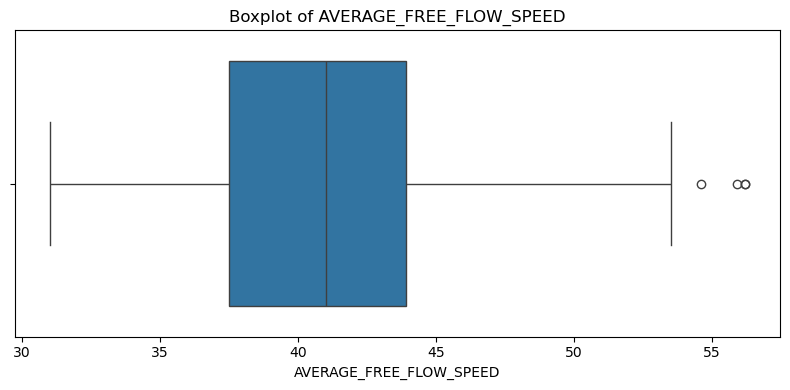

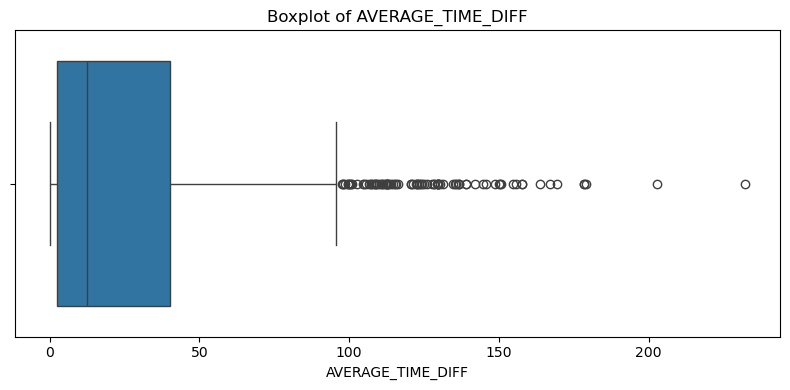

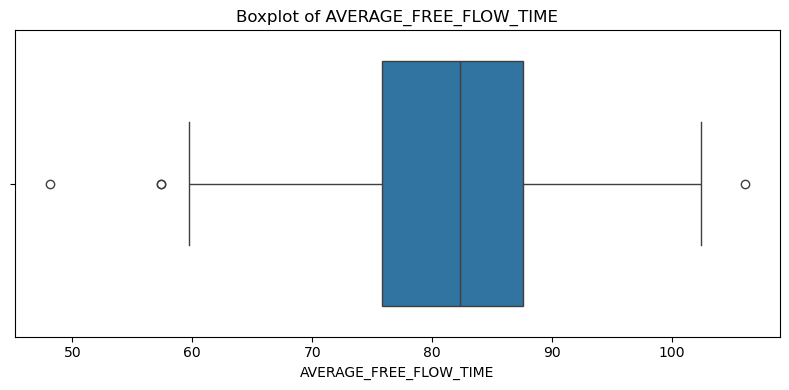

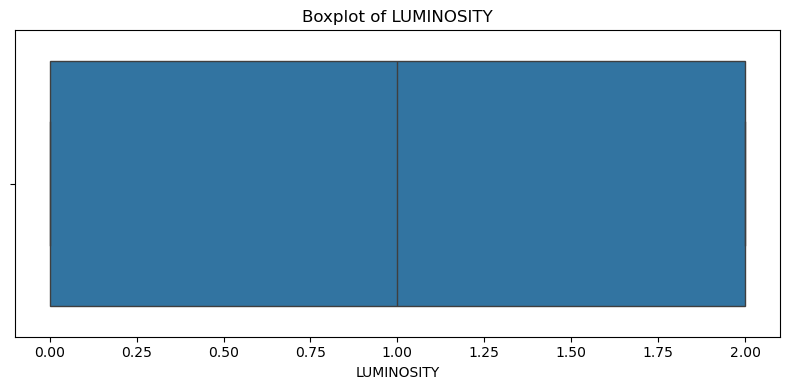

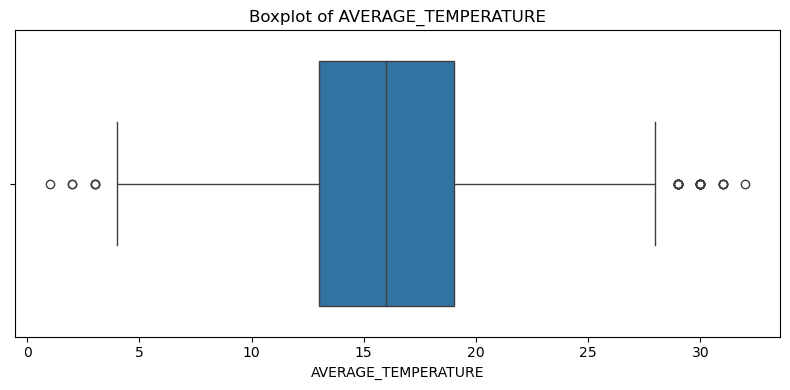

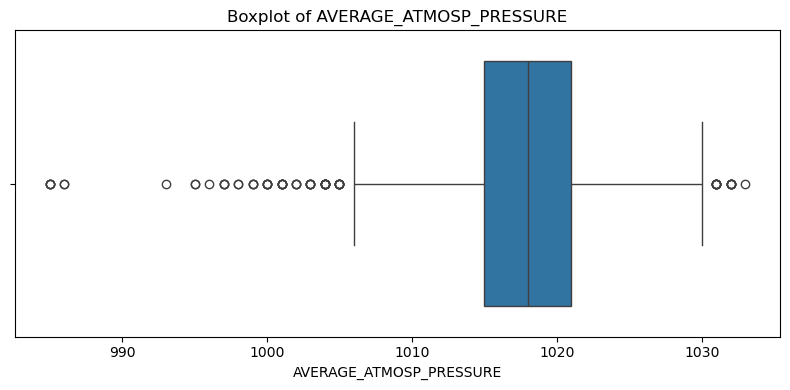

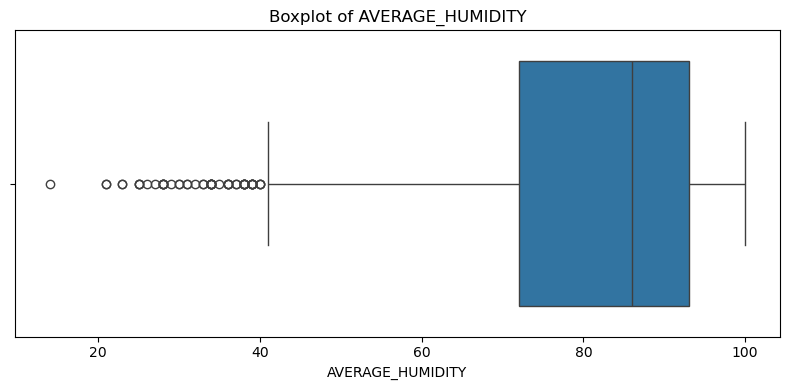

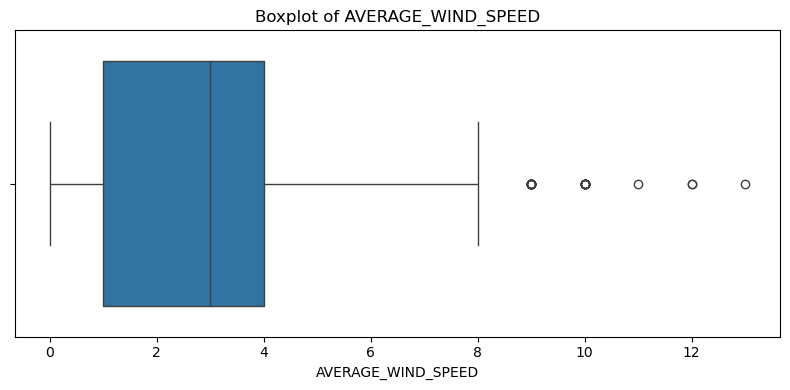

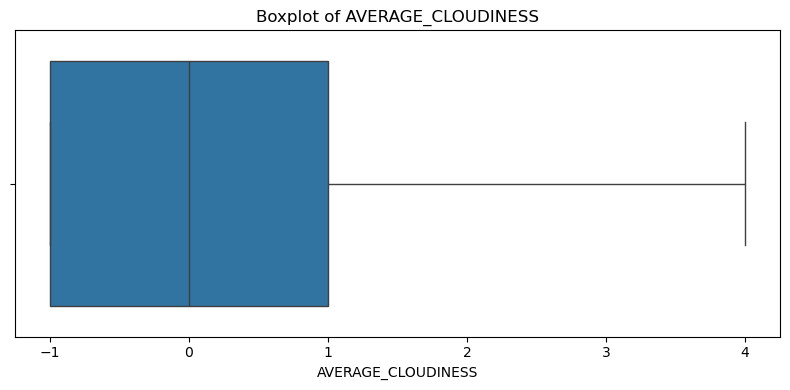

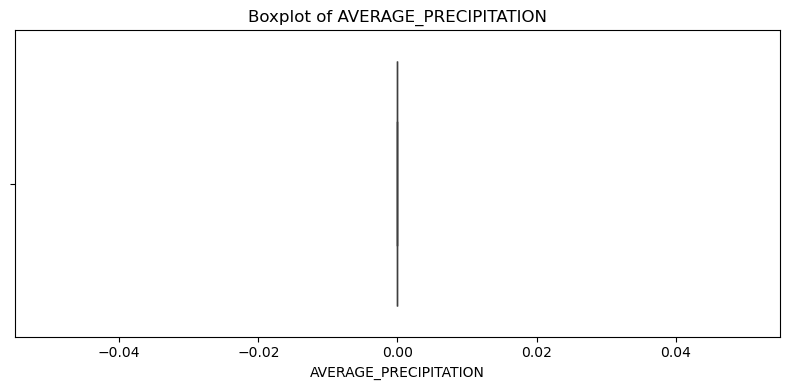

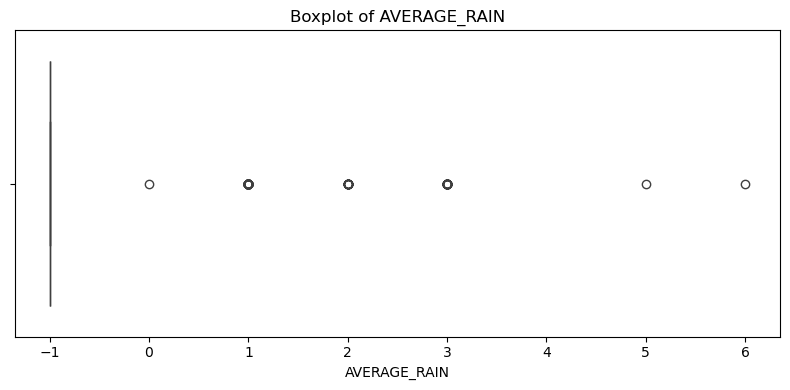

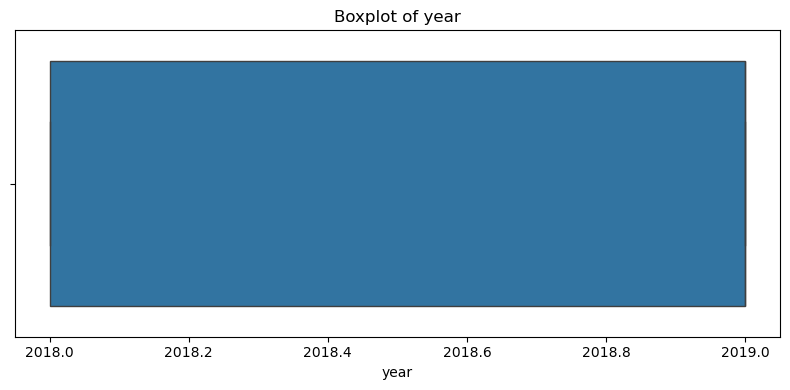

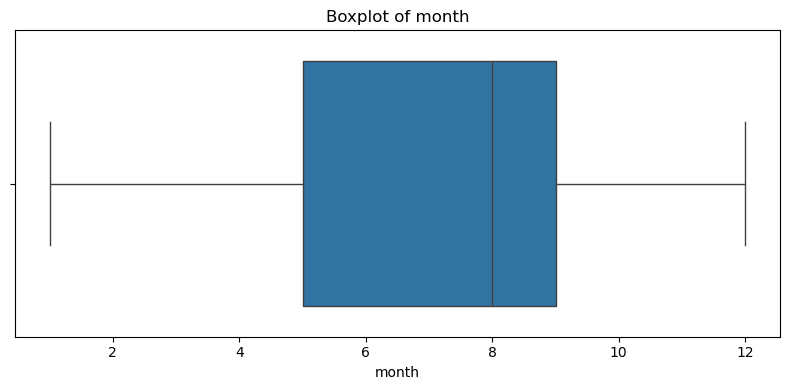

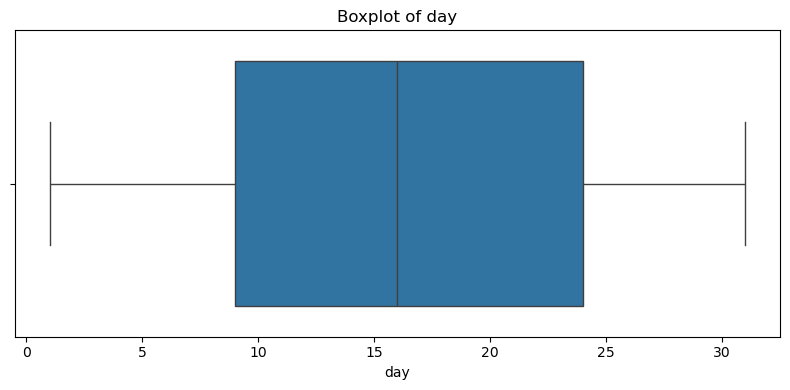

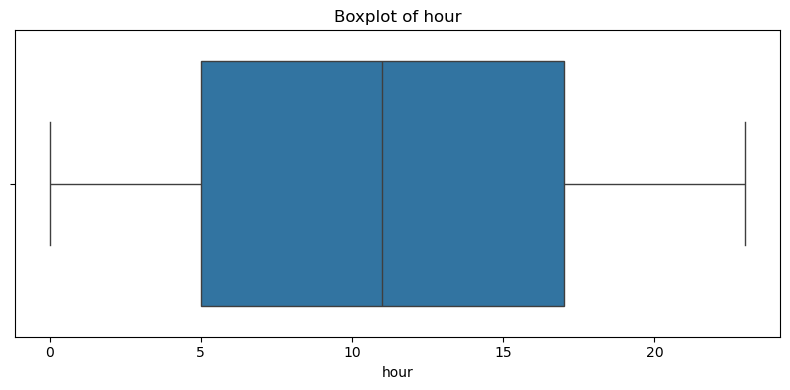

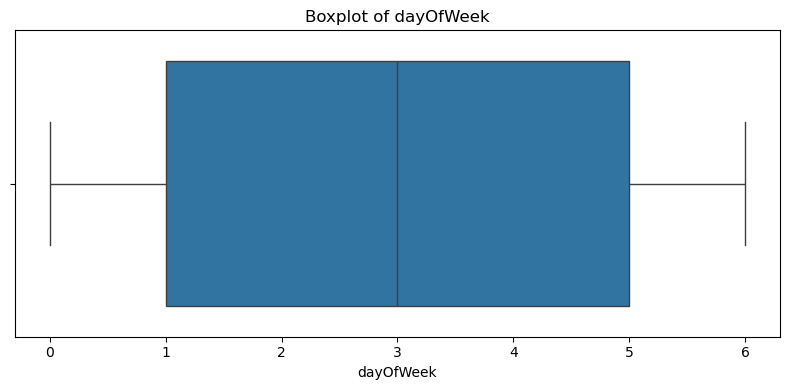

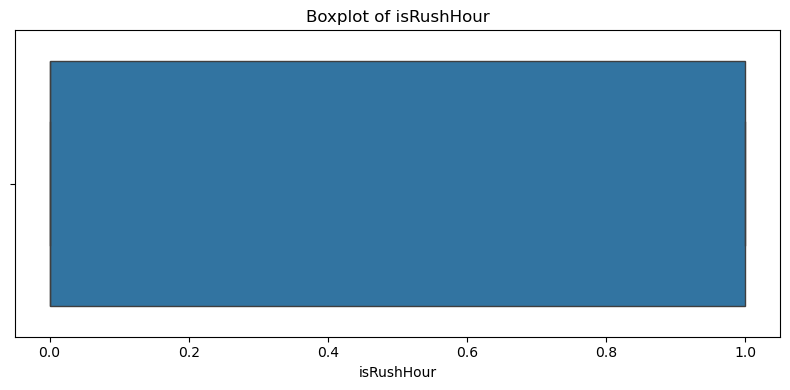

In [22]:
for col in dfTest.columns:
    if pd.api.types.is_numeric_dtype(dfTest[col]):
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=dfTest[col])
        plt.title(f'Boxplot of {col}')
        plt.tight_layout()
        plt.show()

In [23]:
dfTest.nunique()

city_name                     1
record_date                1500
AVERAGE_FREE_FLOW_SPEED     199
AVERAGE_TIME_DIFF           610
AVERAGE_FREE_FLOW_TIME      337
LUMINOSITY                    3
AVERAGE_TEMPERATURE          32
AVERAGE_ATMOSP_PRESSURE      42
AVERAGE_HUMIDITY             70
AVERAGE_WIND_SPEED           14
AVERAGE_CLOUDINESS            6
AVERAGE_PRECIPITATION         1
AVERAGE_RAIN                  7
year                          2
month                        12
day                          31
hour                         24
dayOfWeek                     7
isRushHour                    2
dtype: int64

In [24]:
dfTest.drop(columns=['AVERAGE_PRECIPITATION'], inplace=True)
dfTest.drop(columns=['city_name'], inplace=True)
dfTest.drop(columns=['year'], inplace=True)
dfTest.drop(columns=['month'], inplace=True)
dfTest.drop(columns=['day'], inplace=True)
dfTest.drop(columns=['hour'], inplace=True)

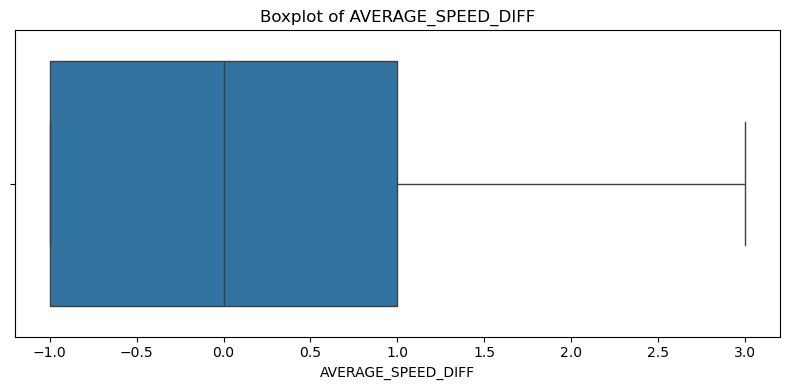

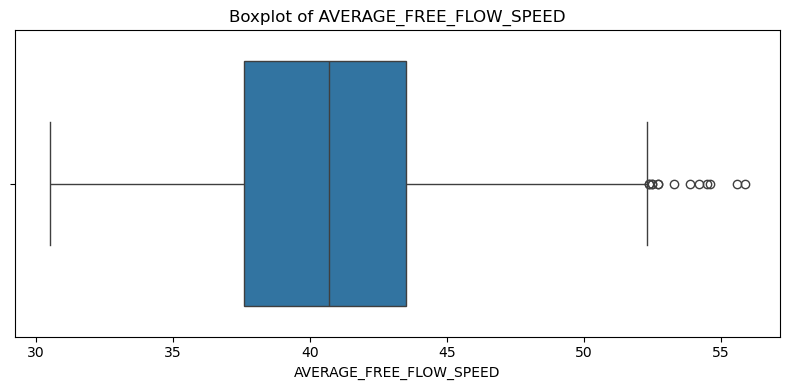

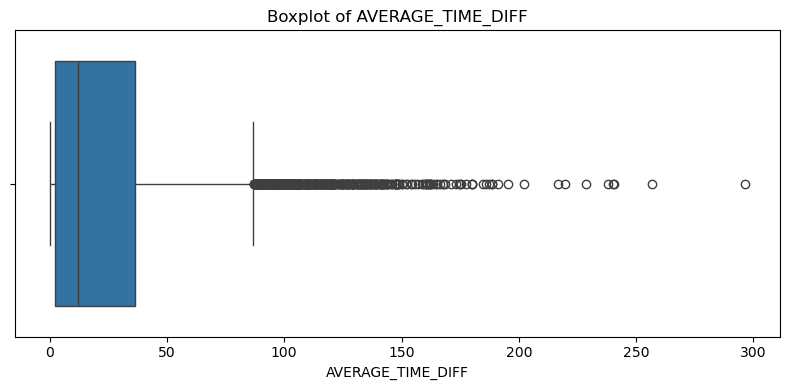

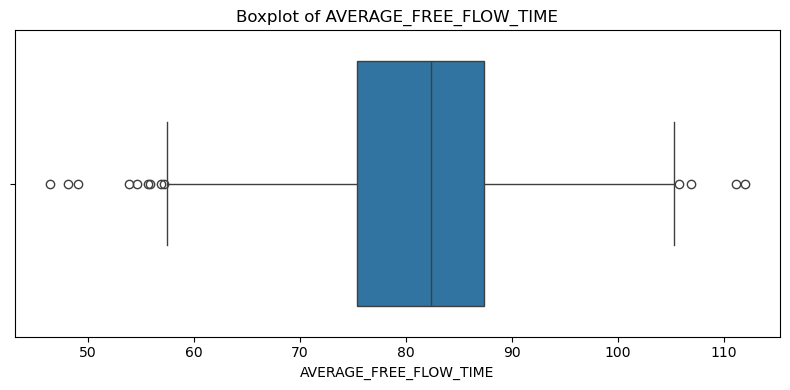

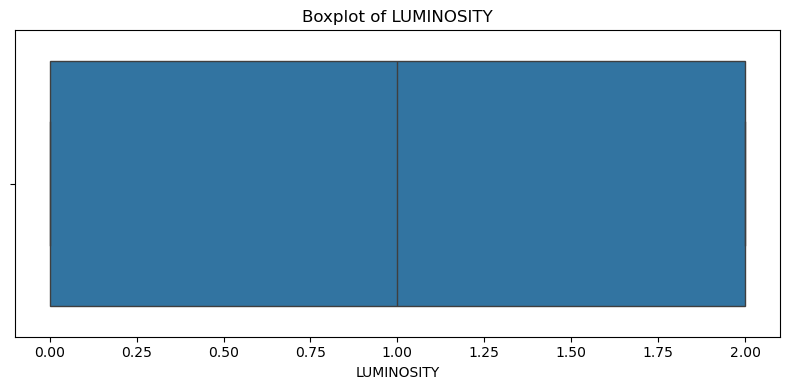

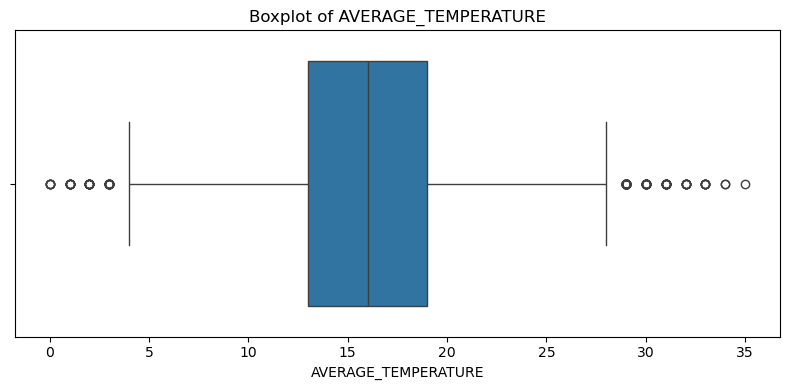

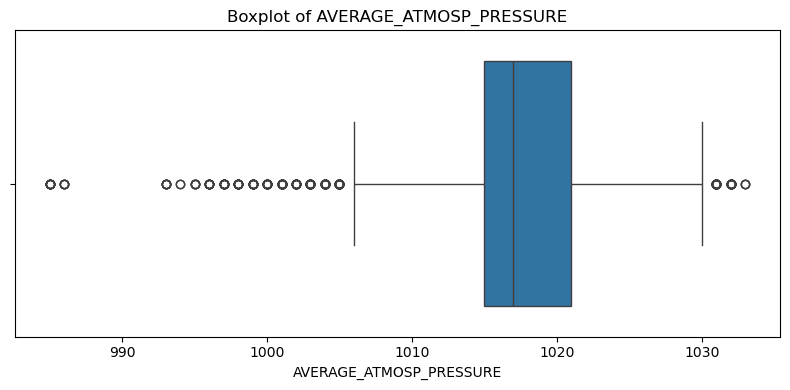

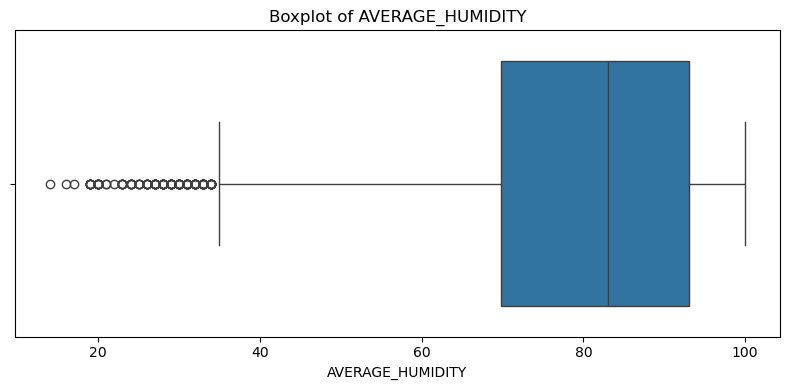

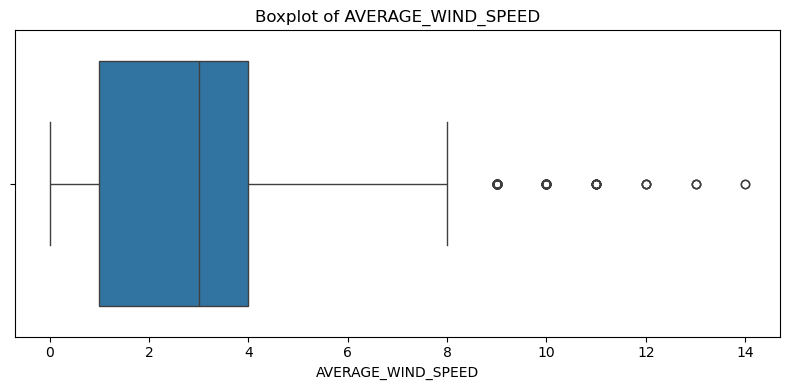

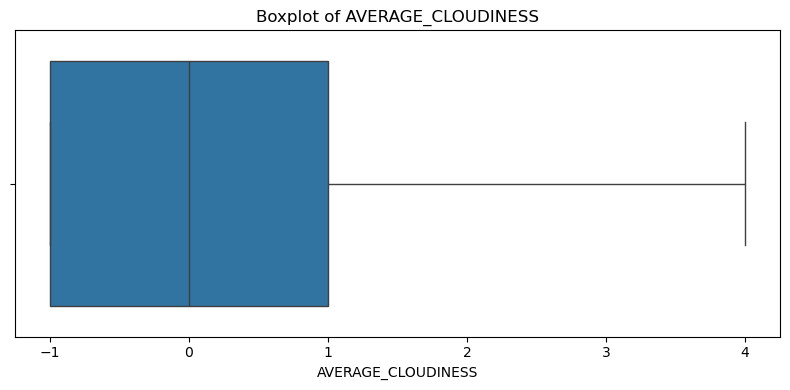

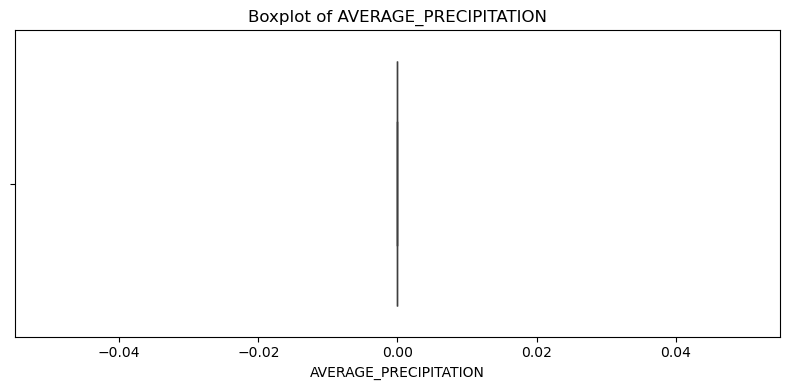

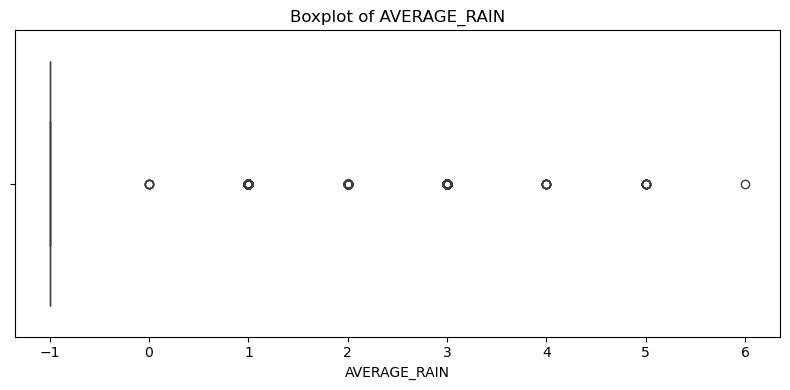

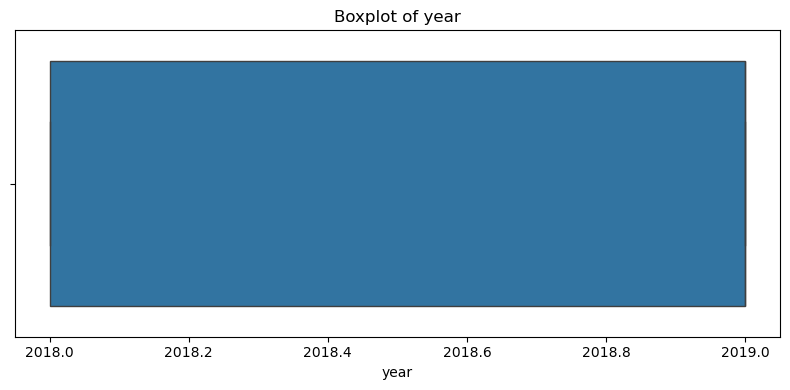

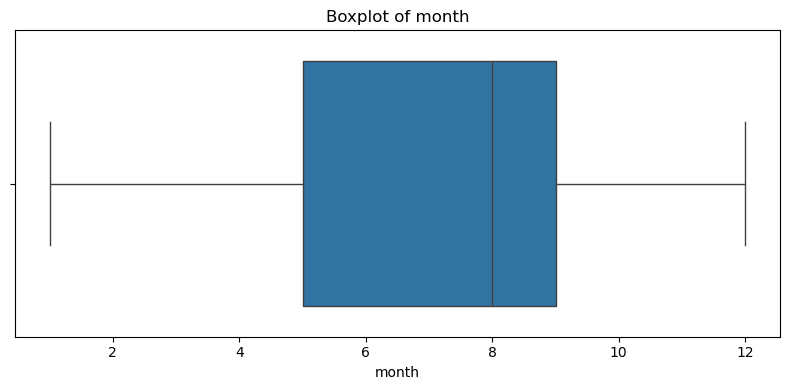

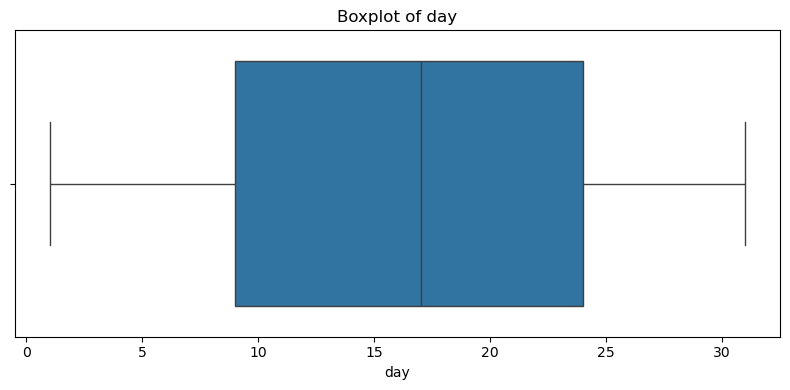

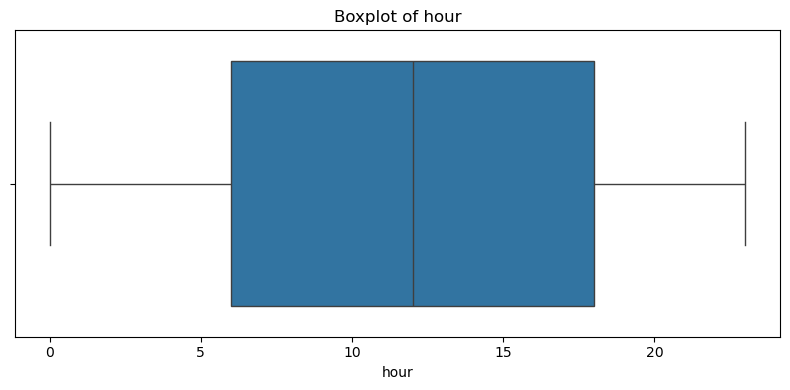

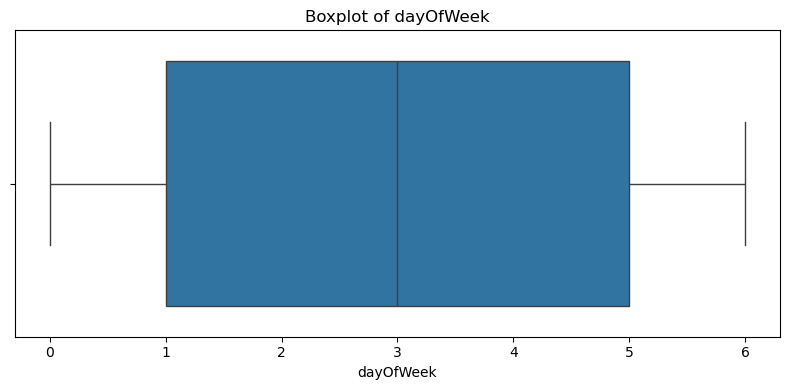

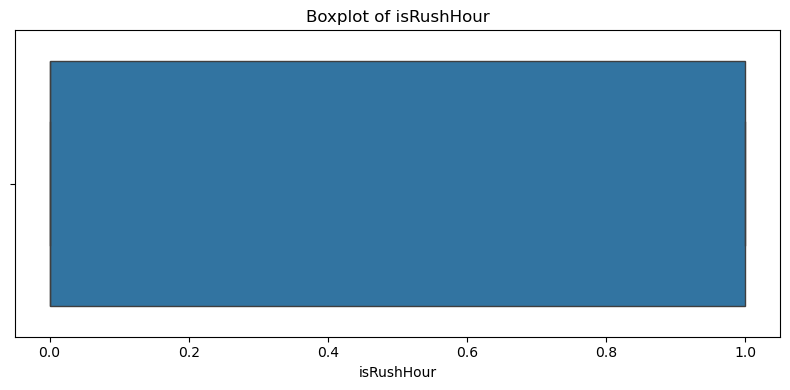

In [25]:
for col in dfTrain.columns:
    if pd.api.types.is_numeric_dtype(dfTrain[col]):
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=dfTrain[col])
        plt.title(f'Boxplot of {col}')
        plt.tight_layout()
        plt.show()

In [26]:
dfTrain.nunique()

city_name                     1
record_date                6812
AVERAGE_SPEED_DIFF            5
AVERAGE_FREE_FLOW_SPEED     225
AVERAGE_TIME_DIFF          1151
AVERAGE_FREE_FLOW_TIME      442
LUMINOSITY                    3
AVERAGE_TEMPERATURE          38
AVERAGE_ATMOSP_PRESSURE      43
AVERAGE_HUMIDITY             77
AVERAGE_WIND_SPEED           15
AVERAGE_CLOUDINESS            6
AVERAGE_PRECIPITATION         1
AVERAGE_RAIN                  8
year                          2
month                        12
day                          31
hour                         24
dayOfWeek                     7
isRushHour                    2
dtype: int64

In [27]:
dfTrain.drop(columns=['AVERAGE_PRECIPITATION'], inplace=True)
dfTrain.drop(columns=['city_name'], inplace=True)
dfTrain.drop(columns=['year'], inplace=True)
dfTrain.drop(columns=['month'], inplace=True)
dfTrain.drop(columns=['day'], inplace=True)
dfTrain.drop(columns=['hour'], inplace=True)

In [28]:
print(dfTest.duplicated().any())

False


In [29]:
print(dfTrain.duplicated().any())

False


In [30]:
print(dfTest.isna().any())

record_date                False
AVERAGE_FREE_FLOW_SPEED    False
AVERAGE_TIME_DIFF          False
AVERAGE_FREE_FLOW_TIME     False
LUMINOSITY                 False
AVERAGE_TEMPERATURE        False
AVERAGE_ATMOSP_PRESSURE    False
AVERAGE_HUMIDITY           False
AVERAGE_WIND_SPEED         False
AVERAGE_CLOUDINESS         False
AVERAGE_RAIN               False
dayOfWeek                  False
isRushHour                 False
dtype: bool


In [31]:
print(dfTrain.isna().any())

record_date                False
AVERAGE_SPEED_DIFF         False
AVERAGE_FREE_FLOW_SPEED    False
AVERAGE_TIME_DIFF          False
AVERAGE_FREE_FLOW_TIME     False
LUMINOSITY                 False
AVERAGE_TEMPERATURE        False
AVERAGE_ATMOSP_PRESSURE    False
AVERAGE_HUMIDITY           False
AVERAGE_WIND_SPEED         False
AVERAGE_CLOUDINESS         False
AVERAGE_RAIN               False
dayOfWeek                  False
isRushHour                 False
dtype: bool


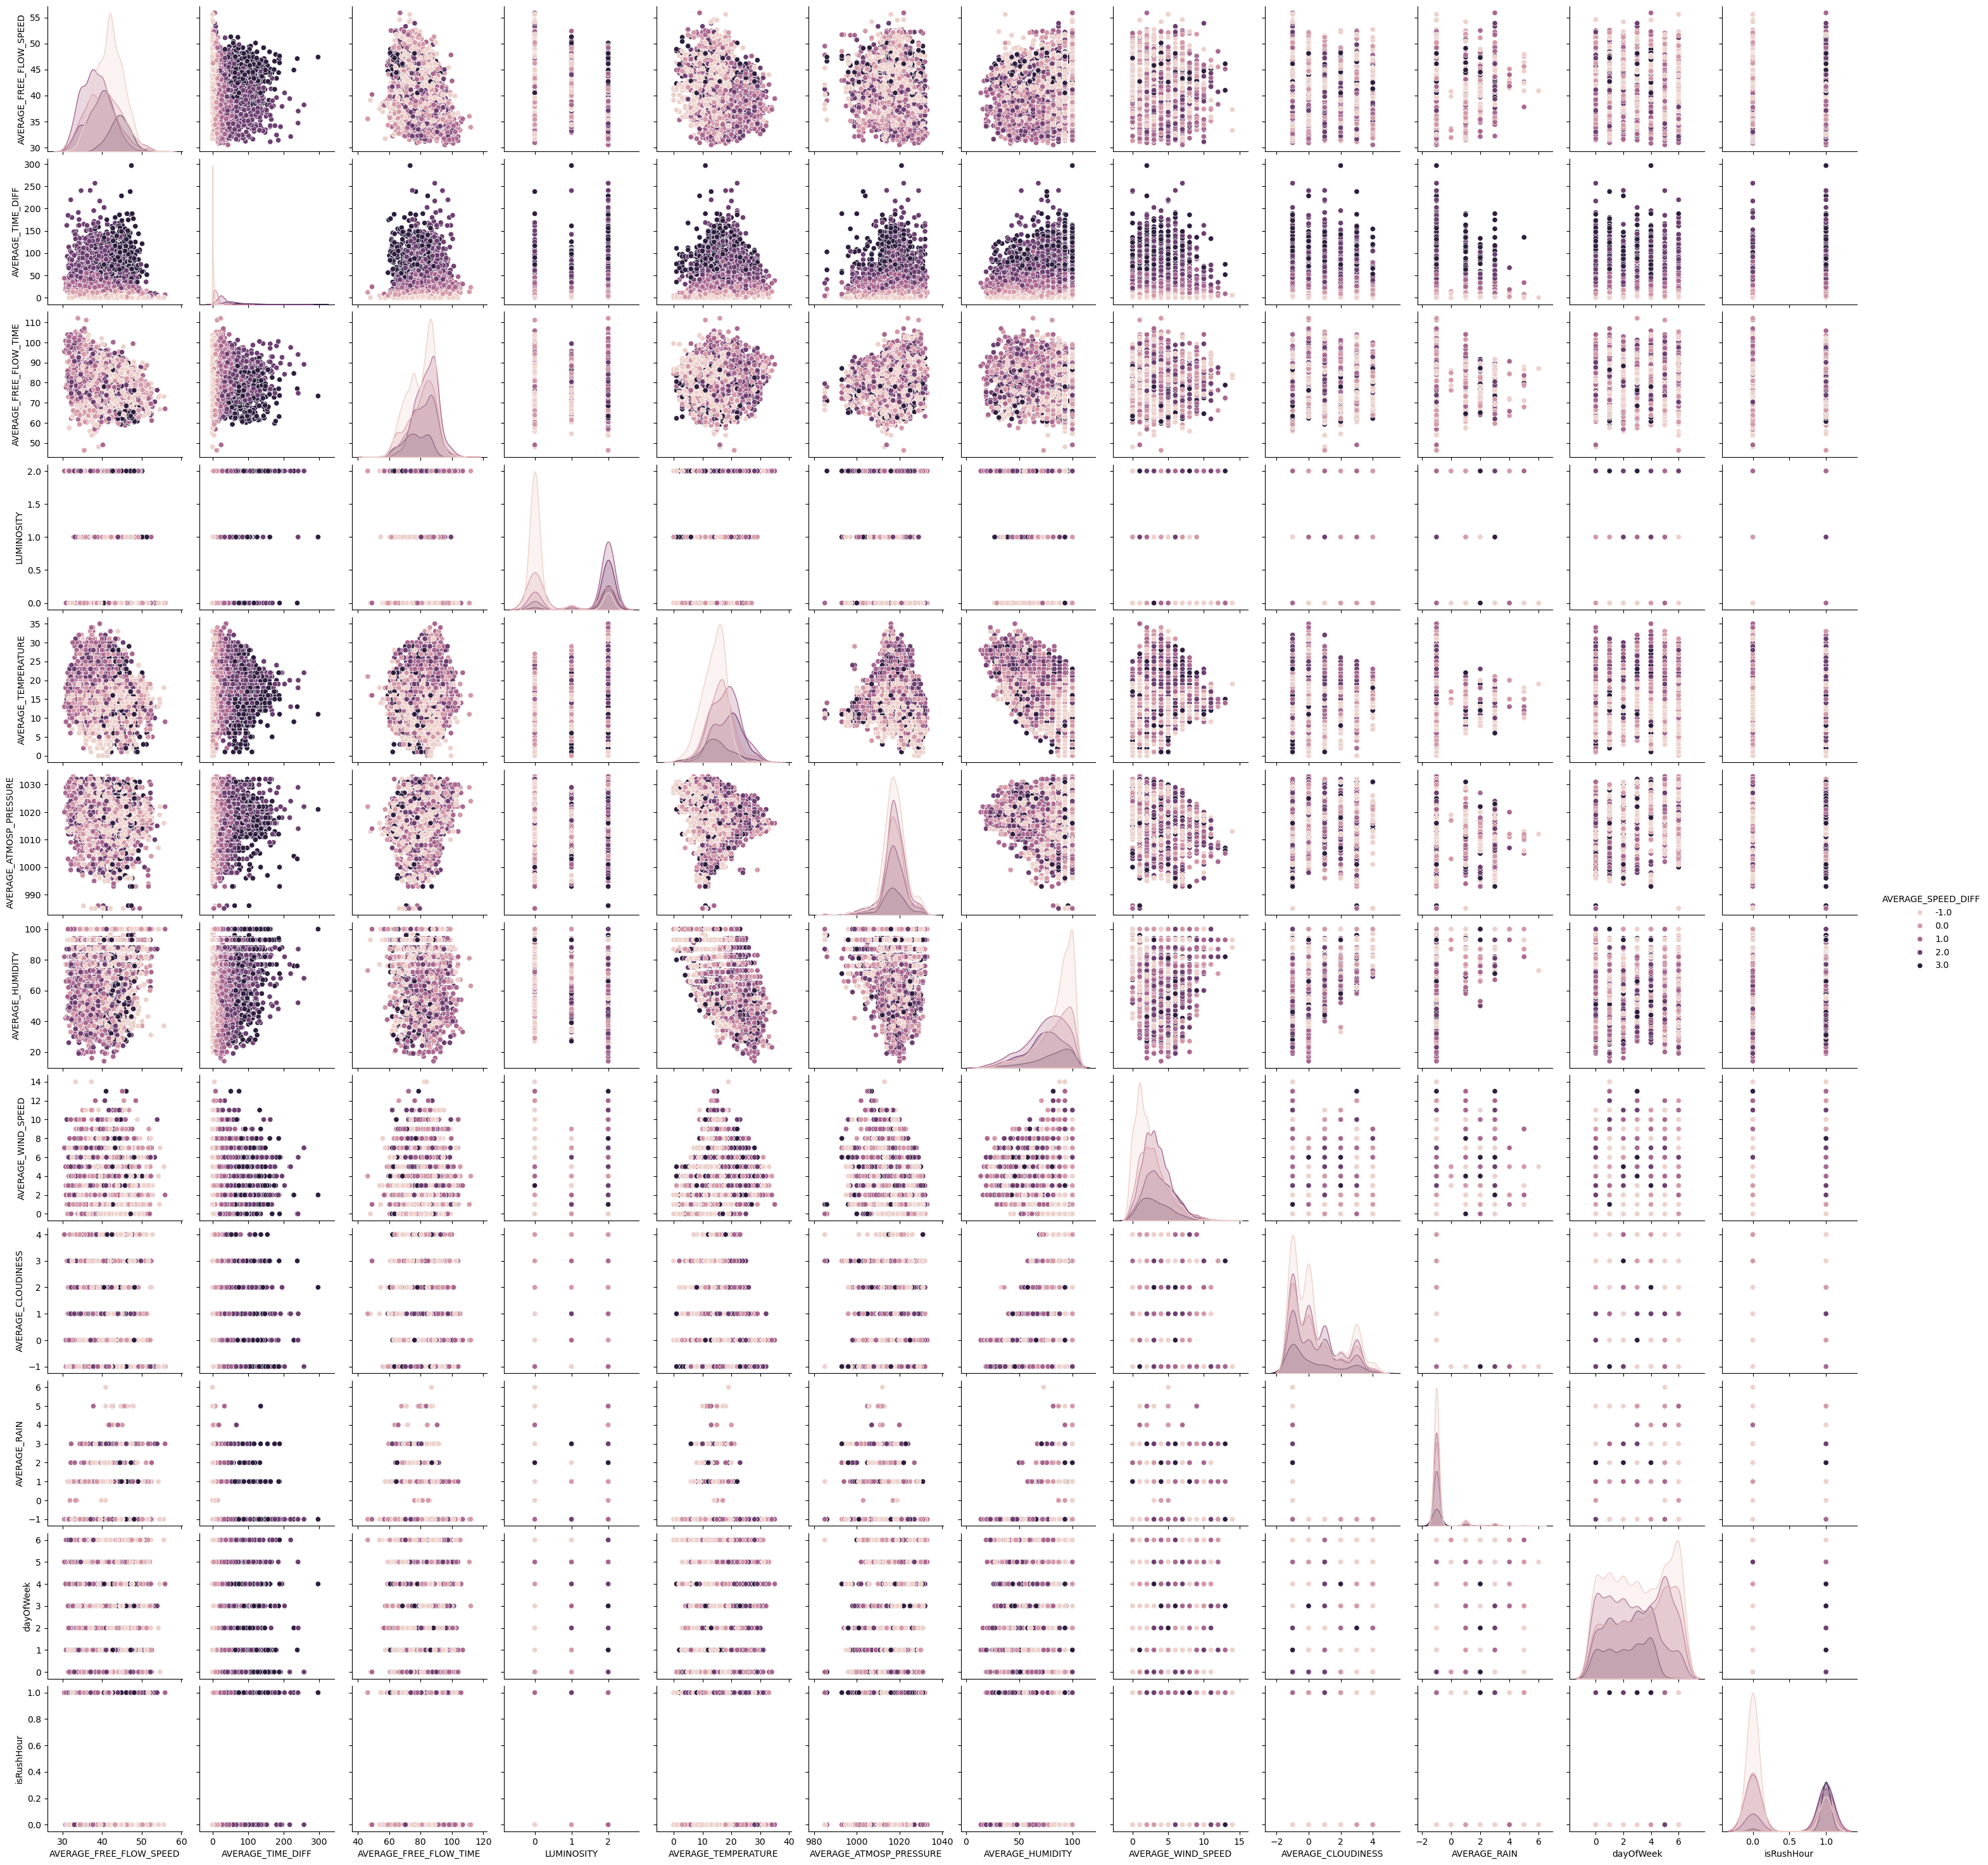

In [32]:
import seaborn as sns
sns.pairplot(dfTrain,hue='AVERAGE_SPEED_DIFF')

In [33]:
dfTrain.columns

Index(['record_date', 'AVERAGE_SPEED_DIFF', 'AVERAGE_FREE_FLOW_SPEED',
       'AVERAGE_TIME_DIFF', 'AVERAGE_FREE_FLOW_TIME', 'LUMINOSITY',
       'AVERAGE_TEMPERATURE', 'AVERAGE_ATMOSP_PRESSURE', 'AVERAGE_HUMIDITY',
       'AVERAGE_WIND_SPEED', 'AVERAGE_CLOUDINESS', 'AVERAGE_RAIN', 'dayOfWeek',
       'isRushHour'],
      dtype='object')

In [34]:
dfTest.columns

Index(['record_date', 'AVERAGE_FREE_FLOW_SPEED', 'AVERAGE_TIME_DIFF',
       'AVERAGE_FREE_FLOW_TIME', 'LUMINOSITY', 'AVERAGE_TEMPERATURE',
       'AVERAGE_ATMOSP_PRESSURE', 'AVERAGE_HUMIDITY', 'AVERAGE_WIND_SPEED',
       'AVERAGE_CLOUDINESS', 'AVERAGE_RAIN', 'dayOfWeek', 'isRushHour'],
      dtype='object')

In [35]:
# Feature Engineering - Criar novas features que capturam relações importantes

# 1. Ratio de atraso (a mais importante!)
# Quanto maior, mais congestionamento
dfTrain['TIME_DELAY_RATIO'] = dfTrain['AVERAGE_TIME_DIFF'] / dfTrain['AVERAGE_FREE_FLOW_TIME']
dfTest['TIME_DELAY_RATIO'] = dfTest['AVERAGE_TIME_DIFF'] / dfTest['AVERAGE_FREE_FLOW_TIME']

# Substituir inf e -inf por 0 (quando FREE_FLOW_TIME é 0)
dfTrain['TIME_DELAY_RATIO'] = dfTrain['TIME_DELAY_RATIO'].replace([np.inf, -np.inf], 0)
dfTest['TIME_DELAY_RATIO'] = dfTest['TIME_DELAY_RATIO'].replace([np.inf, -np.inf], 0)


dfTrain['FREE_FLOW_RATIO'] = dfTrain['AVERAGE_FREE_FLOW_TIME'] / (dfTrain['AVERAGE_FREE_FLOW_TIME'] + dfTrain['AVERAGE_TIME_DIFF'])
dfTest['FREE_FLOW_RATIO'] = dfTest['AVERAGE_FREE_FLOW_TIME'] / (dfTest['AVERAGE_FREE_FLOW_TIME'] + dfTest['AVERAGE_TIME_DIFF'])

dfTrain['FREE_FLOW_RATIO'] = dfTrain['FREE_FLOW_RATIO'].replace([np.inf, -np.inf], 0)
dfTest['FREE_FLOW_RATIO'] = dfTest['FREE_FLOW_RATIO'].replace([np.inf, -np.inf], 0)

# 4. Fim de semana vs dia de semana
dfTrain['IS_WEEKEND'] = (dfTrain['dayOfWeek'] >= 5).astype(int)
dfTest['IS_WEEKEND'] = (dfTest['dayOfWeek'] >= 5).astype(int)

# Dados para treino e teste

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix,ConfusionMatrixDisplay, classification_report

In [37]:
# Separar features e target corretamente
print(dfTrain.columns)
X_treino = dfTrain.drop(columns=[
    'AVERAGE_SPEED_DIFF',
    'record_date',
    'AVERAGE_RAIN',
    'AVERAGE_CLOUDINESS',
    'AVERAGE_WIND_SPEED',
    'AVERAGE_HUMIDITY',
    'AVERAGE_ATMOSP_PRESSURE',
    'LUMINOSITY'])
y_treino = dfTrain['AVERAGE_SPEED_DIFF']

print(dfTest.columns)
X_teste = dfTest.drop(columns=[
    'record_date',
    'AVERAGE_RAIN',
    'AVERAGE_CLOUDINESS',
    'AVERAGE_WIND_SPEED',
    'AVERAGE_HUMIDITY',
    'AVERAGE_ATMOSP_PRESSURE',
    'LUMINOSITY'])

print(f"\nDistribuição do target:")
# -1 NaN até 3 Very_High
print(y_treino.value_counts().sort_index())

Index(['record_date', 'AVERAGE_SPEED_DIFF', 'AVERAGE_FREE_FLOW_SPEED',
       'AVERAGE_TIME_DIFF', 'AVERAGE_FREE_FLOW_TIME', 'LUMINOSITY',
       'AVERAGE_TEMPERATURE', 'AVERAGE_ATMOSP_PRESSURE', 'AVERAGE_HUMIDITY',
       'AVERAGE_WIND_SPEED', 'AVERAGE_CLOUDINESS', 'AVERAGE_RAIN', 'dayOfWeek',
       'isRushHour', 'TIME_DELAY_RATIO', 'FREE_FLOW_RATIO', 'IS_WEEKEND'],
      dtype='object')
Index(['record_date', 'AVERAGE_FREE_FLOW_SPEED', 'AVERAGE_TIME_DIFF',
       'AVERAGE_FREE_FLOW_TIME', 'LUMINOSITY', 'AVERAGE_TEMPERATURE',
       'AVERAGE_ATMOSP_PRESSURE', 'AVERAGE_HUMIDITY', 'AVERAGE_WIND_SPEED',
       'AVERAGE_CLOUDINESS', 'AVERAGE_RAIN', 'dayOfWeek', 'isRushHour',
       'TIME_DELAY_RATIO', 'FREE_FLOW_RATIO', 'IS_WEEKEND'],
      dtype='object')

Distribuição do target:
AVERAGE_SPEED_DIFF
-1.0    2200
 0.0    1419
 1.0    1651
 2.0    1063
 3.0     479
Name: count, dtype: int64


In [38]:
# Dividir dados para treino e validação
X_train, X_val, y_train, y_val = train_test_split(
    X_treino, y_treino, 
    test_size=0.3, 
    random_state=2020, 
    stratify=y_treino
)

In [39]:
# Implementar GridSearchCV/Random e outros modelos depois
rfClassifier = RandomForestClassifier(
    n_estimators=750,
    max_depth=None,
    min_samples_split=200,
    min_samples_leaf=100,
    max_features='log2',
    bootstrap=True,
    criterion='gini',
    n_jobs=-1,
    random_state=42,
    verbose=0
)

# Treinar o modelo
rfClassifier.fit(X_train, y_train)

# Fazer predições
y_pred_train = rfClassifier.predict(X_train)
y_pred_val = rfClassifier.predict(X_val)

print("\n=== RESULTADOS NO TREINO ===")
print(f"Accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"F1-Score (weighted): {f1_score(y_train, y_pred_train, average='weighted'):.4f}")

print("\n=== RESULTADOS NA VALIDAÇÃO ===")
print(f"Accuracy: {accuracy_score(y_val, y_pred_val):.4f}")
print(f"F1-Score (weighted): {f1_score(y_val, y_pred_val, average='weighted'):.4f}")


=== RESULTADOS NO TREINO ===
Accuracy: 0.7747
F1-Score (weighted): 0.7736

=== RESULTADOS NA VALIDAÇÃO ===
Accuracy: 0.7598
F1-Score (weighted): 0.7585



Validação
              precision    recall  f1-score   support

     Unknown       0.84      0.90      0.87       660
         Low       0.63      0.67      0.65       426
      Medium       0.77      0.64      0.70       495
        High       0.70      0.79      0.74       319
   Very_High       0.91      0.69      0.79       144

    accuracy                           0.76      2044
   macro avg       0.77      0.74      0.75      2044
weighted avg       0.76      0.76      0.76      2044



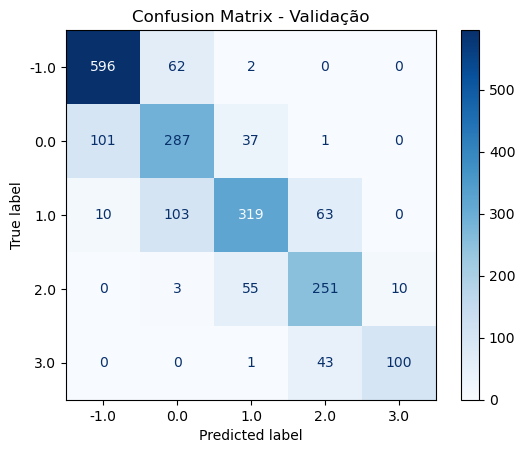

In [40]:
print("\nValidação")

targetNames = ['Unknown', 'Low', 'Medium', 'High', 'Very_High']

print(classification_report(y_val, y_pred_val, target_names=targetNames))
cm = confusion_matrix(y_val, y_pred_val, labels=rfClassifier.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rfClassifier.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Validação")
plt.show()

In [41]:
y_pred_teste = rfClassifier.predict(X_teste)

# Criar arquivo de submissão com Speed_Diff
row_ids = range(1, len(dfTest) + 1)
mapping_reverse = {0: 'Low', 1: 'Medium', 2: 'High', 3: 'Very_High', -1: 'None'}

y_pred_teste_labels = [mapping_reverse[int(pred)] for pred in y_pred_teste]

output = pd.DataFrame({
    'RowId': row_ids,
    'Speed_Diff': y_pred_teste_labels
})

# Salvar em CSV
output.to_csv('submission_random_forest.csv', index=False)

print(output['Speed_Diff'].value_counts())

Speed_Diff
None         500
Low          328
Medium       308
High         285
Very_High     79
Name: count, dtype: int64
